# Gradient Boosting (XGBoost) — IT25104115 - Muhadh M.R
### Mental-health history prediction (binary classification: **No / Yes**)

## Step A — Environment Setup: settings, imports, load data

In [1]:
# ===================== SETTINGS (the only cell you might need to edit) =====================
QUICK_RUN    = False   # True = small, fast run just to check everything works
DATA_DIR     = None    # None = find the data automatically, or e.g. r"C:\path\to\data\prepared"
TUNING_ROWS  = 18000   # rows used for the hyperparameter search (final model uses ALL training rows)
N_ITER       = 15      # hyperparameter combinations to try
TUNING_CV    = 3       # CV folds during tuning
FINAL_CV     = 5       # CV folds for the final cross-validation check
RANDOM_STATE = 42
OUTPUT_DIR   = "gradient_boosting_outputs"   # charts, summary and saved model go here
# ============================================================================================
if QUICK_RUN:
    TUNING_ROWS, N_ITER, TUNING_CV, FINAL_CV = 6000, 4, 3, 3

import time, zipfile, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, classification_report, confusion_matrix, roc_curve
)

try:
    import xgboost as xgb
except ImportError:
    raise ImportError("XGBoost is not installed. Run  !pip install xgboost  in a new cell, then restart the kernel and run again.")

warnings.filterwarnings("ignore", category=UserWarning)
OUT = Path(OUTPUT_DIR); OUT.mkdir(exist_ok=True)
print(f"Libraries loaded (XGBoost {xgb.__version__}).  Quick run: {QUICK_RUN}")

Libraries loaded (XGBoost 3.4.1).  Quick run: False


In [2]:
# Find the dataset automatically: next to this notebook, in the project folder, or inside the .zip
NEEDED = ["X_train.csv", "X_test.csv", "y_train.csv", "y_test.csv"]

def find_data_folder():
    here = Path.cwd()
    candidates = ([Path(DATA_DIR)] if DATA_DIR else []) + [
        here, here / "data" / "prepared",
        here / "Gradient_Boosting_Project" / "data" / "prepared",
        here.parent / "data" / "prepared", here / "_dataset_from_zip",
    ]
    for c in candidates:
        if all((c / f).exists() for f in NEEDED):
            return c, "folder"
    for z in sorted(here.glob("*.zip")) + sorted(here.parent.glob("*.zip")):
        try:
            with zipfile.ZipFile(z) as zf:
                wanted = NEEDED + ["tuning_train_positions.npy"]
                members = {Path(n).name: n for n in zf.namelist()
                           if "data/prepared/" in n and Path(n).name in wanted}
                if all(f in members for f in NEEDED):
                    out = here / "_dataset_from_zip"; out.mkdir(exist_ok=True)
                    for name, member in members.items():
                        (out / name).write_bytes(zf.read(member))
                    return out, f"zip ({z.name})"
        except zipfile.BadZipFile:
            continue
    raise FileNotFoundError(
        "Could not find the dataset. Put 'Gradient_Boosting_Project_fixed.zip' in the same folder as this "
        "notebook (current folder: " + str(here) + "), or set DATA_DIR in the settings cell to the folder "
        "that contains X_train.csv, X_test.csv, y_train.csv and y_test.csv.")

data_dir, source = find_data_folder()
print(f">> Data found via {source}: {data_dir}")

X_train = pd.read_csv(data_dir / "X_train.csv")
X_test  = pd.read_csv(data_dir / "X_test.csv")
y_train = pd.read_csv(data_dir / "y_train.csv").iloc[:, 0].astype(int)
y_test  = pd.read_csv(data_dir / "y_test.csv").iloc[:, 0].astype(int)

assert list(X_train.columns) == list(X_test.columns), "Train/test columns do not match"
assert len(X_train) == len(y_train) and len(X_test) == len(y_test), "Row counts do not match"
assert X_train.isna().sum().sum() == 0 and X_test.isna().sum().sum() == 0, "Unexpected missing values"

FEATURES   = list(X_train.columns)
NUMERIC    = [c for c in ["Age", "Number of Children", "Income"] if c in FEATURES]
TARGET     = y_train.name
CLASS_NAMES = ["No", "Yes"]
print("Data loaded.")

>> Data found via folder: C:\Users\HP\Downloads\Gradient_Boosting_Project_fixed\Gradient_Boosting_Project\data\prepared


Data loaded.


In [3]:
neg, pos = int((y_train == 0).sum()), int((y_train == 1).sum())
SCALE_POS_WEIGHT = neg / pos     # tells XGBoost to take the rarer "Yes" class seriously

print(f"Target: {TARGET}   (0 = No, 1 = Yes)")
print(f"Train shape: {X_train.shape}   Test shape: {X_test.shape}   Features: {len(FEATURES)}")
print(f"Train class balance:  No = {neg:,} ({neg/len(y_train):.1%})   Yes = {pos:,} ({pos/len(y_train):.1%})")
print(f"scale_pos_weight = {SCALE_POS_WEIGHT:.2f}")

# Tuning subset (uses the group's saved row positions when available, so results match teammates)
pos_file = data_dir / "tuning_train_positions.npy"
if pos_file.exists():
    tune_idx = np.load(pos_file)
else:
    tune_idx = np.random.RandomState(RANDOM_STATE).permutation(len(X_train))
tune_idx = tune_idx[:TUNING_ROWS]
X_tune, y_tune = X_train.iloc[tune_idx].reset_index(drop=True), y_train.iloc[tune_idx].reset_index(drop=True)
print(f"Tuning subset: {len(X_tune):,} rows")

# --- helpers used by every later step ---
def make_model(**params):
    """Scales Age / Children / Income, then runs XGBoost. Accepts RAW (unscaled) inputs."""
    prep = ColumnTransformer([("scale", StandardScaler(), NUMERIC)],
                             remainder="passthrough", verbose_feature_names_out=False)
    prep.set_output(transform="pandas")
    clf = xgb.XGBClassifier(objective="binary:logistic", eval_metric="logloss", tree_method="hist",
                            scale_pos_weight=SCALE_POS_WEIGHT, random_state=RANDOM_STATE, n_jobs=-1, **params)
    return Pipeline([("prep", prep), ("model", clf)])

def metrics(y_true, pred, proba):
    return {
        "Accuracy":            accuracy_score(y_true, pred),
        "Precision (Yes)":     precision_score(y_true, pred, zero_division=0),
        "Recall (Yes)":        recall_score(y_true, pred, zero_division=0),
        "F1 (Yes)":            f1_score(y_true, pred, zero_division=0),
        "F1 (macro)":          f1_score(y_true, pred, average="macro"),
        "ROC-AUC":             roc_auc_score(y_true, proba),
        "Average precision":   average_precision_score(y_true, proba),
    }
X_train.head()

Target: History of Mental Illness   (0 = No, 1 = Yes)
Train shape: (326888, 24)   Test shape: (81723, 24)   Features: 24
Train class balance:  No = 227,108 (69.5%)   Yes = 99,780 (30.5%)
scale_pos_weight = 2.28
Tuning subset: 18,000 rows


,Age,Number of Children,Income,History of Substance Abuse,Family History of Depression,Chronic Medical Conditions,Marital Status_Married,Marital Status_Single,Marital Status_Widowed,Education Level_Bachelor's Degree,...,Smoking Status_Non-smoker,Physical Activity Level_Moderate,Physical Activity Level_Sedentary,Employment Status_Unemployed,Alcohol Consumption_Low,Alcohol Consumption_Moderate,Dietary Habits_Moderate,Dietary Habits_Unhealthy,Sleep Patterns_Good,Sleep Patterns_Poor
0,70,3,73411.54,0,1,0,0,0,1,1,...,0,1,0,0,0,0,0,0,0,0
1,54,2,41223.14,0,0,1,1,0,0,0,...,1,0,1,0,0,1,1,0,0,1
2,73,0,61437.47,0,0,0,1,0,0,0,...,1,0,1,0,0,1,1,0,0,0
3,21,0,57418.96,1,0,1,1,0,0,0,...,0,1,0,0,0,1,1,0,1,0
4,49,2,27149.77,0,0,0,1,0,0,0,...,0,0,1,0,1,0,0,1,0,0


## Step B — Baseline Model (XGBoost defaults)

In [4]:
t0 = time.time()
baseline = make_model()
baseline.fit(X_train, y_train)
print(f"Baseline model trained in {time.time()-t0:.1f}s.")

Baseline model trained in 2.7s.


In [5]:
base_train = metrics(y_train, baseline.predict(X_train), baseline.predict_proba(X_train)[:, 1])
base_test  = metrics(y_test,  baseline.predict(X_test),  baseline.predict_proba(X_test)[:, 1])

print("--- Baseline results ---")
print(pd.DataFrame({"Train": base_train, "Test": base_test}).round(4).to_string())

--- Baseline results ---
                    Train    Test
Accuracy           0.5962  0.5671
Precision (Yes)    0.3985  0.3684
Recall (Yes)       0.6337  0.5854
F1 (Yes)           0.4893  0.4522
F1 (macro)         0.5777  0.5472
ROC-AUC            0.6493  0.5970
Average precision  0.4425  0.3701


## Step C — Hyperparameter Tuning

Tries `N_ITER` random combinations with cross-validation on the tuning subset, scored on **F1 for the "Yes" class**. This is the slowest cell — a few minutes on a normal laptop (about a minute with `QUICK_RUN = True`).

In [6]:
param_dist = {
    "model__n_estimators":     [100, 200, 300],
    "model__max_depth":        [2, 3, 4, 5, 6],
    "model__learning_rate":    [0.01, 0.03, 0.05, 0.1],
    "model__subsample":        [0.7, 0.8, 1.0],
    "model__min_child_weight": [1, 5, 10, 20],
    "model__colsample_bytree": [0.7, 1.0],
}
print(f"Searching {N_ITER} combinations x {TUNING_CV}-fold CV on {len(X_tune):,} rows ({N_ITER*TUNING_CV} fits)...")
t0 = time.time()
search = RandomizedSearchCV(
    make_model(),
    param_distributions=param_dist,
    n_iter=N_ITER,
    scoring="f1",
    cv=StratifiedKFold(n_splits=TUNING_CV, shuffle=True, random_state=RANDOM_STATE),
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=1,
)
search.fit(X_tune, y_tune)
BEST_PARAMS = {k.replace("model__", ""): v for k, v in search.best_params_.items()}
print(f"Tuning complete in {time.time()-t0:.0f}s.")

Searching 15 combinations x 3-fold CV on 18,000 rows (45 fits)...
Fitting 3 folds for each of 15 candidates, totalling 45 fits


Tuning complete in 44s.


In [7]:
print("Best hyperparameters found:")
for k, v in BEST_PARAMS.items():
    print(f"  {k}: {v}")
print(f"\nBest CV F1 (Yes class) during search: {search.best_score_:.4f}")

# Retrain with the best settings on the FULL training set
t0 = time.time()
best_model = make_model(**BEST_PARAMS)
best_model.fit(X_train, y_train)
print(f"Final model trained on all {len(X_train):,} training rows in {time.time()-t0:.1f}s.")

Best hyperparameters found:
  subsample: 0.8
  n_estimators: 200
  min_child_weight: 1
  max_depth: 3
  learning_rate: 0.03
  colsample_bytree: 1.0

Best CV F1 (Yes class) during search: 0.4530


Final model trained on all 326,888 training rows in 4.6s.


## Step D — Evaluation

In [8]:
train_pred  = best_model.predict(X_train)
test_pred   = best_model.predict(X_test)
train_proba = best_model.predict_proba(X_train)[:, 1]
test_proba  = best_model.predict_proba(X_test)[:, 1]

res = metrics(y_test, test_pred, test_proba)
acc, prec_yes, rec_yes, f1_yes, f1_macro, auc, ap = res.values()
prec_macro   = precision_score(y_test, test_pred, average="macro")
rec_macro    = recall_score(y_test, test_pred, average="macro")
prec_weighted = precision_score(y_test, test_pred, average="weighted")
rec_weighted  = recall_score(y_test, test_pred, average="weighted")
f1_weighted   = f1_score(y_test, test_pred, average="weighted")

print("--- Tuned model — test set metrics ---")
print(f"Accuracy:              {acc:.4f}")
print(f"Precision (Yes):       {prec_yes:.4f}")
print(f"Recall (Yes):          {rec_yes:.4f}")
print(f"F1 (Yes):              {f1_yes:.4f}")
print(f"Precision (macro):     {prec_macro:.4f}")
print(f"Recall (macro):        {rec_macro:.4f}")
print(f"F1 (macro):            {f1_macro:.4f}")
print(f"Precision (weighted):  {prec_weighted:.4f}")
print(f"Recall (weighted):     {rec_weighted:.4f}")
print(f"F1 (weighted):         {f1_weighted:.4f}")
print(f"ROC-AUC:               {auc:.4f}   (0.5 = coin flip, 1.0 = perfect)")
print(f"Average precision:     {ap:.4f}")

print("\n--- Baseline vs tuned (test set) ---")
print(pd.DataFrame({"Baseline": base_test, "Tuned": res}).round(4).to_string())

--- Tuned model — test set metrics ---
Accuracy:              0.5911
Precision (Yes):       0.3798
Recall (Yes):          0.5365
F1 (Yes):              0.4448
Precision (macro):     0.5656
Recall (macro):        0.5758
F1 (macro):            0.5606
Precision (weighted):  0.6379
Recall (weighted):     0.5911
F1 (weighted):         0.6057
ROC-AUC:               0.6028   (0.5 = coin flip, 1.0 = perfect)
Average precision:     0.3756

--- Baseline vs tuned (test set) ---
                   Baseline   Tuned
Accuracy             0.5671  0.5911
Precision (Yes)      0.3684  0.3798
Recall (Yes)         0.5854  0.5365
F1 (Yes)             0.4522  0.4448
F1 (macro)           0.5472  0.5606
ROC-AUC              0.5970  0.6028
Average precision    0.3701  0.3756


In [9]:
print("Full classification report:\n")
print(classification_report(y_test, test_pred, target_names=CLASS_NAMES, digits=3))

Full classification report:

              precision    recall  f1-score   support

          No      0.751     0.615     0.676     56778
         Yes      0.380     0.536     0.445     24945

    accuracy                          0.591     81723
   macro avg      0.566     0.576     0.561     81723
weighted avg      0.638     0.591     0.606     81723



In [10]:
# Overfitting check: compare train vs test performance
train_acc = accuracy_score(y_train, train_pred)
train_f1  = f1_score(y_train, train_pred)
gap = train_acc - acc

print(f"Train accuracy: {train_acc:.4f}   Test accuracy: {acc:.4f}   Gap: {gap:.4f}")
print(f"Train F1 (Yes): {train_f1:.4f}   Test F1 (Yes): {f1_yes:.4f}   Gap: {train_f1 - f1_yes:.4f}")
print("\n(A gap under ~0.03-0.05 is generally healthy; a bigger gap suggests overfitting.)")

Train accuracy: 0.5899   Test accuracy: 0.5911   Gap: -0.0013
Train F1 (Yes): 0.4428   Test F1 (Yes): 0.4448   Gap: -0.0020

(A gap under ~0.03-0.05 is generally healthy; a bigger gap suggests overfitting.)


In [11]:
# Cross-validation of the tuned model (on the tuning subset, so it finishes quickly)
skf = StratifiedKFold(n_splits=FINAL_CV, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(clone(best_model), X_tune, y_tune, cv=skf, scoring="f1", n_jobs=1)

print(f"{FINAL_CV}-fold CV F1 (Yes) scores:", np.round(cv_scores, 4))
print(f"Mean: {cv_scores.mean():.4f}   Std: {cv_scores.std():.4f}")

5-fold CV F1 (Yes) scores: [0.4347 0.4616 0.4583 0.4603 0.4572]
Mean: 0.4544   Std: 0.0100


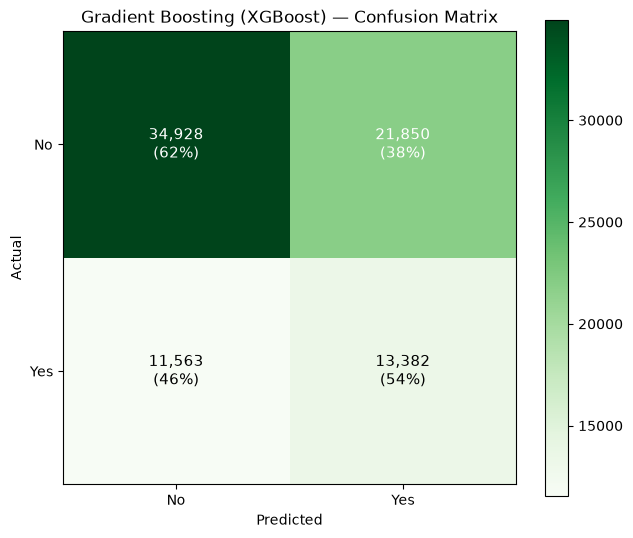

Saved gradient_boosting_outputs\GradientBoosting_confusion_matrix.png


In [12]:
# Confusion matrix (counts, with % of each actual class underneath)
cm = confusion_matrix(y_test, test_pred)
cm_pct = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(cm, cmap="Greens")
ax.set_xticks(range(2)); ax.set_yticks(range(2))
ax.set_xticklabels(CLASS_NAMES); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Gradient Boosting (XGBoost) — Confusion Matrix")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}\n({cm_pct[i, j]:.0%})", ha="center", va="center", fontsize=11,
                color="white" if cm[i, j] > cm.max() / 2 else "black")
fig.colorbar(im)
fig.tight_layout()
fig.savefig(OUT / "GradientBoosting_confusion_matrix.png", dpi=150)
plt.show()
print(f"Saved {OUT / 'GradientBoosting_confusion_matrix.png'}")

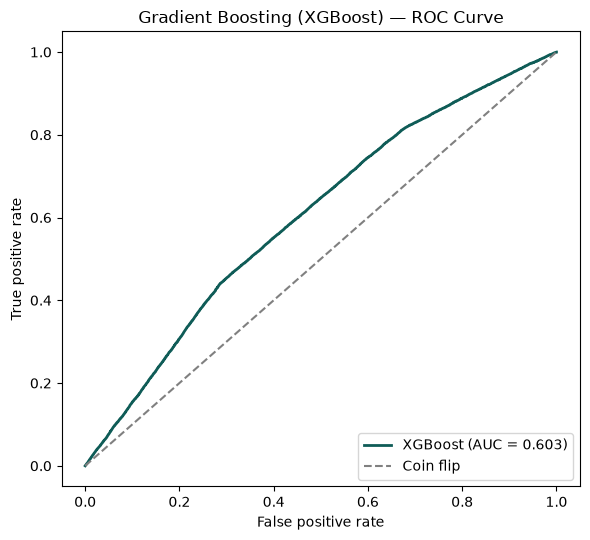

Saved gradient_boosting_outputs\GradientBoosting_roc_curve.png


In [13]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, test_proba)
fig_roc, ax_roc = plt.subplots(figsize=(6, 5.5))
ax_roc.plot(fpr, tpr, color="#0F5C57", lw=2, label=f"XGBoost (AUC = {auc:.3f})")
ax_roc.plot([0, 1], [0, 1], "--", color="grey", label="Coin flip")
ax_roc.set_xlabel("False positive rate"); ax_roc.set_ylabel("True positive rate")
ax_roc.set_title("Gradient Boosting (XGBoost) — ROC Curve"); ax_roc.legend(loc="lower right")
fig_roc.tight_layout()
fig_roc.savefig(OUT / "GradientBoosting_roc_curve.png", dpi=150)
plt.show()
print(f"Saved {OUT / 'GradientBoosting_roc_curve.png'}")

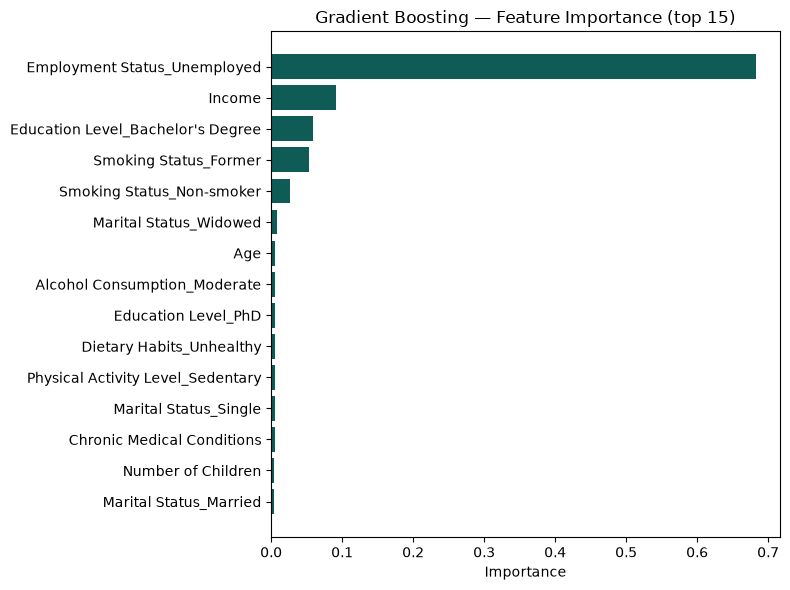

Saved gradient_boosting_outputs\GradientBoosting_feature_importance.png


In [14]:
# Feature importance (top 15)
names = list(best_model.named_steps["prep"].get_feature_names_out())
importances = best_model.named_steps["model"].feature_importances_
order = np.argsort(importances)[::-1]
top = order[:15]

fig2, ax2 = plt.subplots(figsize=(8, 6))
ax2.barh([names[i] for i in top], importances[top], color="#0F5C57")
ax2.set_xlabel("Importance")
ax2.set_title("Gradient Boosting — Feature Importance (top 15)")
ax2.invert_yaxis()
fig2.tight_layout()
fig2.savefig(OUT / "GradientBoosting_feature_importance.png", dpi=150)
plt.show()
print(f"Saved {OUT / 'GradientBoosting_feature_importance.png'}")

## Step E — Documentation for Group Comparison

Generates the summary text for the group comparison table and saves the trained model so you can reuse it without retraining.

In [15]:
summary = f"""
MODEL SUMMARY — Gradient Boosting (XGBoost) — IT25104121 Ahamed M.A.S
========================================================
Target: {TARGET} (No / Yes)     Train rows: {len(X_train):,}   Test rows: {len(X_test):,}
Best hyperparameters: {BEST_PARAMS}
(tuned on {len(X_tune):,} rows, {N_ITER} combinations x {TUNING_CV}-fold CV, scored on F1 for "Yes")

Cross-validation ({FINAL_CV}-fold, tuning subset):
  F1 (Yes) mean: {cv_scores.mean():.4f}  (std: {cv_scores.std():.4f})

Test set metrics:
  Accuracy:             {acc:.4f}
  Precision (Yes):      {prec_yes:.4f}
  Recall (Yes):         {rec_yes:.4f}
  F1 (Yes):             {f1_yes:.4f}
  Precision (macro):    {prec_macro:.4f}
  Recall (macro):       {rec_macro:.4f}
  F1 (macro):           {f1_macro:.4f}
  F1 (weighted):        {f1_weighted:.4f}
  ROC-AUC:              {auc:.4f}

Overfitting check:
  Train accuracy: {train_acc:.4f}
  Test accuracy:  {acc:.4f}
  Gap:            {gap:.4f}

Top feature: {names[order[0]]} (importance {importances[order[0]]:.3f})

Confusion matrix, ROC curve and feature importance charts are saved as PNG
files in the '{OUTPUT_DIR}' folder — share them with the group.
========================================================
"""
print(summary)

(OUT / "GradientBoosting_summary.txt").write_text(summary, encoding="utf-8")
joblib.dump({"pipeline": best_model, "features": FEATURES, "numeric": NUMERIC,
             "classes": CLASS_NAMES, "best_params": BEST_PARAMS},
            OUT / "GradientBoosting_xgb_model.joblib")
print(f"Saved summary and model to the '{OUTPUT_DIR}' folder.")


MODEL SUMMARY — Gradient Boosting (XGBoost) — IT25104121 Ahamed M.A.S
Target: History of Mental Illness (No / Yes)     Train rows: 326,888   Test rows: 81,723
Best hyperparameters: {'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 1.0}
(tuned on 18,000 rows, 15 combinations x 3-fold CV, scored on F1 for "Yes")

Cross-validation (5-fold, tuning subset):
  F1 (Yes) mean: 0.4544  (std: 0.0100)

Test set metrics:
  Accuracy:             0.5911
  Precision (Yes):      0.3798
  Recall (Yes):         0.5365
  F1 (Yes):             0.4448
  Precision (macro):    0.5656
  Recall (macro):       0.5758
  F1 (macro):           0.5606
  F1 (weighted):        0.6057
  ROC-AUC:              0.6028

Overfitting check:
  Train accuracy: 0.5899
  Test accuracy:  0.5911
  Gap:            -0.0013

Top feature: Employment Status_Unemployed (importance 0.683)

Confusion matrix, ROC curve and feature importance charts are saved as PNG
f